# Práctica 1 — Parte 1: Regresión (precio de viviendas)


## Dependencias

Ejecutar la primera celda de código una vez.


In [1]:
import subprocess
import sys

PIP_DEPS = [
    "numpy>=1.24",
    "pandas>=2.0",
    "matplotlib>=3.7",
    "seaborn>=0.13",
    "scipy>=1.10",
    "scikit-learn>=1.3",
    "xgboost>=2.0",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", *PIP_DEPS])
print("Instalado con:", sys.executable)


Instalado con: d:\Code, 3D, Audio\Coding\GitHub\UNAL-ML\.venv\Scripts\python.exe


## 1. Configuración

Rutas desde la carpeta del proyecto (`datos/`).


In [3]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import loguniform, randint, uniform

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

for _style in ("seaborn-v0_8-whitegrid", "seaborn-whitegrid", "ggplot"):
    try:
        plt.style.use(_style)
        break
    except OSError:
        continue
sns.set_palette("deep")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path.cwd() if (Path.cwd() / "datos" / "regresion" / "houseprices.csv").exists() else Path.cwd().parent
DATA_PATH = ROOT / "datos" / "regresion" / "houseprices.csv"

try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None
    print("Instala xgboost: pip install xgboost")

print("Datos:", DATA_PATH.resolve())


Datos: D:\Code, 3D, Audio\Coding\GitHub\UNAL-ML\practica_1\datos\regresion\houseprices.csv


## 2. Datos


In [8]:
df = pd.read_csv(DATA_PATH)
df.shape
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## 3. Preprocesamiento


In [10]:
TARGET = "SalePrice"

if TARGET not in df.columns:
    raise ValueError(f"Falta la columna objetivo {TARGET!r}")

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype(float).copy()

if "Id" in X.columns:
    X = X.drop(columns=["Id"])

if "MSSubClass" in X.columns:
    X["MSSubClass"] = X["MSSubClass"].astype(str)

num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numéricas:", len(num_cols), "| Categóricas:", len(cat_cols))


Numéricas: 35 | Categóricas: 44


C:\Users\yulcr\AppData\Local\Temp\ipykernel_24000\2950584033.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


In [11]:
numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", ohe),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
X_train.shape, X_test.shape


((1168, 79), (292, 79))

## 4. Modelos y evaluación


In [12]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
N_ITER = 24


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_on_test(name, estimator):
    pred = estimator.predict(X_test)
    return {
        "modelo": name,
        "RMSE_test": rmse(y_test, pred),
        "MAE_test": mean_absolute_error(y_test, pred),
        "R2_test": r2_score(y_test, pred),
    }


rows = []
fitted = {}

pipe_lr = Pipeline([("prep", preprocessor), ("model", LinearRegression())])
pipe_lr.fit(X_train, y_train)
fitted["LinearRegression"] = pipe_lr
rows.append({**evaluate_on_test("LinearRegression", pipe_lr), "best_params": {}})

search_specs = [
    (
        "Ridge",
        Ridge(),
        {"model__alpha": loguniform(1e-4, 1e2)},
    ),
    (
        "Lasso",
        Lasso(random_state=RANDOM_STATE, max_iter=20000),
        {"model__alpha": loguniform(1e-4, 10.0)},
    ),
    (
        "ElasticNet",
        ElasticNet(random_state=RANDOM_STATE, max_iter=20000),
        {
            "model__alpha": loguniform(1e-4, 10.0),
            "model__l1_ratio": uniform(0.1, 0.8),
        },
    ),
    (
        "MLPRegressor",
        MLPRegressor(
            random_state=RANDOM_STATE,
            max_iter=800,
            early_stopping=True,
            n_iter_no_change=15,
        ),
        {
            "model__hidden_layer_sizes": [(64,), (128,), (64, 64), (128, 64)],
            "model__alpha": loguniform(1e-5, 1e-1),
            "model__learning_rate_init": loguniform(1e-4, 1e-2),
        },
    ),
    (
        "RandomForestRegressor",
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {
            "model__n_estimators": randint(80, 400),
            "model__max_depth": [None] + list(range(8, 35, 3)),
            "model__min_samples_leaf": randint(1, 8),
            "model__max_features": ["sqrt", "log2", None],
        },
    ),
]

if XGBRegressor is not None:
    search_specs.append(
        (
            "XGBRegressor",
            XGBRegressor(
                random_state=RANDOM_STATE,
                n_jobs=-1,
                objective="reg:squarederror",
            ),
            {
                "model__n_estimators": randint(100, 600),
                "model__max_depth": randint(3, 12),
                "model__learning_rate": loguniform(0.01, 0.3),
                "model__subsample": uniform(0.6, 0.35),
                "model__colsample_bytree": uniform(0.6, 0.35),
            },
        )
    )

for name, est, param_dist in search_specs:
    pipe = Pipeline([("prep", preprocessor), ("model", est)])
    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_dist,
        n_iter=N_ITER,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X_train, y_train)
    fitted[name] = search.best_estimator_
    row = evaluate_on_test(name, search.best_estimator_)
    row["best_params"] = search.best_params_
    rows.append(row)

results = pd.DataFrame(rows)
results["RMSE_test"] = results["RMSE_test"].astype(float)
results = results.sort_values("RMSE_test").reset_index(drop=True)
results


,modelo,RMSE_test,MAE_test,R2_test,best_params
0,XGBRegressor,24186.644390,15280.626311,0.923733,{'model__colsample_bytree': 0.7836647510712832...
1,Lasso,27826.574361,17389.867634,0.899050,{'model__alpha': 7.072114131472227}
2,LinearRegression,29304.265276,18096.935560,0.888044,{}
3,ElasticNet,30746.245052,19023.558858,0.876755,"{'model__alpha': 0.01444525102276306, 'model__..."
4,Ridge,30901.092304,18903.579912,0.875510,{'model__alpha': 15.741890047456648}
5,MLPRegressor,32216.628877,18774.272112,0.864685,"{'model__alpha': 0.00021618942406574428, 'mode..."
6,RandomForestRegressor,33423.869755,18274.561172,0.854354,"{'model__max_depth': 23, 'model__max_features'..."


## 5. Gráficos


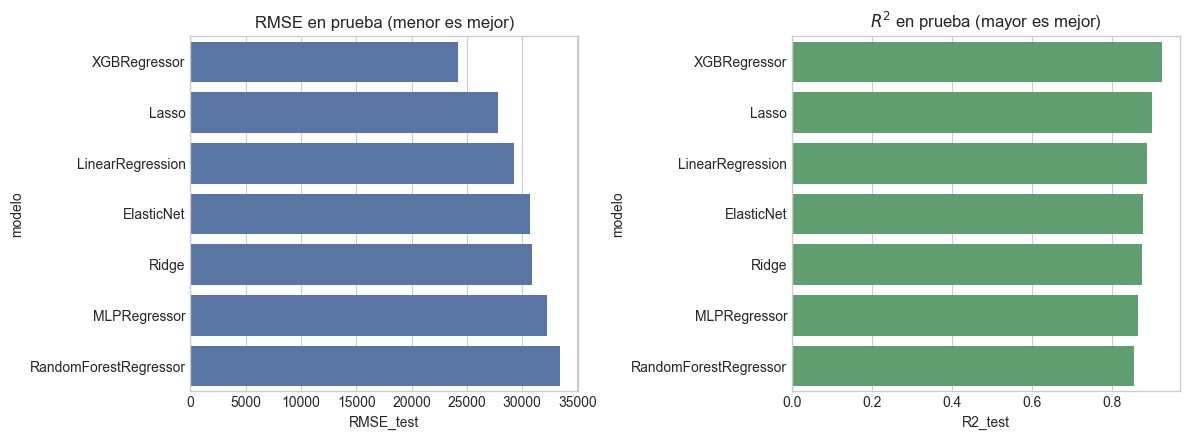

In [13]:
plot_df = results[["modelo", "RMSE_test", "MAE_test", "R2_test"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=plot_df, y="modelo", x="RMSE_test", ax=axes[0], color="#4C72B0")
axes[0].set_title("RMSE en prueba (menor es mejor)")
sns.barplot(data=plot_df, y="modelo", x="R2_test", ax=axes[1], color="#55A868")
axes[1].set_title(r"$R^2$ en prueba (mayor es mejor)")
plt.tight_layout()
plt.show()


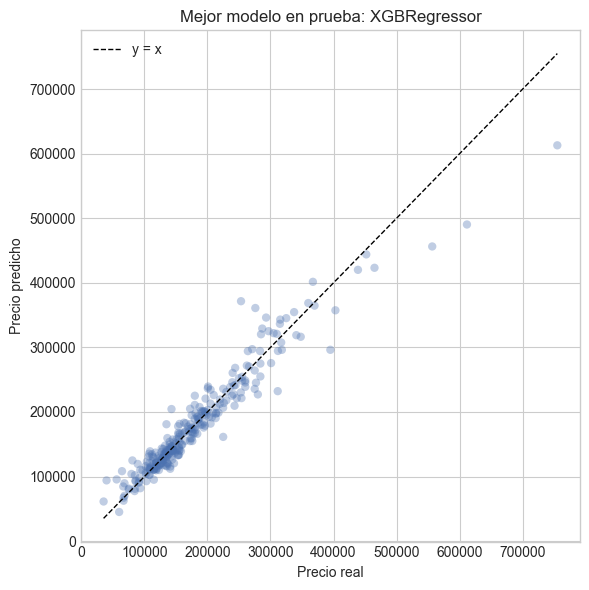

In [14]:
best_name = results.loc[0, "modelo"]
best_model = fitted[best_name]
pred_test = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred_test, alpha=0.35, edgecolors="none")
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
ax.plot(lims, lims, "k--", lw=1, label="y = x")
ax.set_xlabel("Precio real")
ax.set_ylabel("Precio predicho")
ax.set_title(f"Mejor modelo en prueba: {best_name}")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Hiperparámetros


In [15]:
for _, r in results.iterrows():
    print(r["modelo"], "->", r["best_params"])


XGBRegressor -> {'model__colsample_bytree': np.float64(0.7836647510712832), 'model__learning_rate': np.float64(0.04345454109729477), 'model__max_depth': 3, 'model__n_estimators': 574, 'model__subsample': np.float64(0.8141485131528328)}
Lasso -> {'model__alpha': np.float64(7.072114131472227)}
LinearRegression -> {}
ElasticNet -> {'model__alpha': np.float64(0.01444525102276306), 'model__l1_ratio': np.float64(0.3329833121584336)}
Ridge -> {'model__alpha': np.float64(15.741890047456648)}
MLPRegressor -> {'model__alpha': np.float64(0.00021618942406574428), 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': np.float64(0.0026070247583707684)}
RandomForestRegressor -> {'model__max_depth': 23, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 246}


In [19]:
top = results.iloc[0]
second = results.iloc[1] if len(results) > 1 else None

print(f"Mejor modelo: {top['modelo']}")
print(
    f"  RMSE prueba: {top['RMSE_test']:,.0f}  |  MAE: {top['MAE_test']:,.0f}  |  R²: {top['R2_test']:.4f}"
)

if second is not None:
    delta_rmse = second["RMSE_test"] - top["RMSE_test"]
    delta_r2 = top["R2_test"] - second["R2_test"]
    print(f"\nSegundo: {second['modelo']}")
    print(
        f"  RMSE prueba: {second['RMSE_test']:,.0f}  |  R²: {second['R2_test']:.4f}"
    )
    print(
        f"\nVentaja del ganador: ~{delta_rmse:,.0f} USD menos de RMSE en prueba que el segundo; "
        f"R² superior en {delta_r2:.4f}."
    )


Mejor modelo: XGBRegressor
  RMSE prueba: 24,187  |  MAE: 15,281  |  R²: 0.9237

Segundo: Lasso
  RMSE prueba: 27,827  |  R²: 0.8991

Ventaja del ganador: ~3,640 USD menos de RMSE en prueba que el segundo; R² superior en 0.0247.


## 7. Resultados

La tabla de modelos (ordenada por RMSE en prueba) resume el rendimiento con una partición fija train/test. **XGBRegressor** encabeza el ranking con RMSE ≈ 24.2k USD, MAE ≈ 15.3k y **R² ≈ 0.92**, es decir, explica una parte muy alta de la varianza del precio en el conjunto de prueba y mantiene errores medios acotados en las mismas unidades que `SalePrice`.

El **segundo lugar** lo ocupa **Lasso**, con RMSE ≈ 27.8k y R² ≈ 0.90. La ventaja del ganador es del orden de **~3.6k USD menos de RMSE** y **~0.025 más de R²**, que es una mejora clara pero no desorbitada: los modelos lineales bien regularizados siguen siendo muy competitivos cuando las variables categóricas pasan por *one-hot* y las relaciones no son demasiado rígidas.

**ElasticNet** y **Ridge** quedan en un bloque intermedio; **MLPRegressor** y **RandomForestRegressor** aparecen por detrás en esta corrida concreta. Eso no etiqueta a los algoritmos como “peores” en general: comparten preprocesamiento (imputación, escalado, *one-hot*) y la búsqueda aleatoria tiene **variedad finita** (`n_iter`), de modo que con otra semilla o más iteraciones el orden podría moverse, sobre todo entre modelos de árboles.

Las **barras** de RMSE y R² reflejan el mismo ordenamiento: menor barra azul y mayor barra verde para XGBoost, y degradación gradual hacia Random Forest en esta ejecución.

El gráfico **precio real vs predicho** del mejor modelo muestra puntos muy alineados con la diagonal en el rango medio (donde hay más casas), coherente con un R² alto. En precios muy altos suele haber más dispersión y tendencia a **subestimar** casas caras o atípicas (pocos ejemplos en la cola); conviene citar algún **outlier** muy alejado de la diagonal como limitación del ajuste y del tamaño muestral en esa zona.
